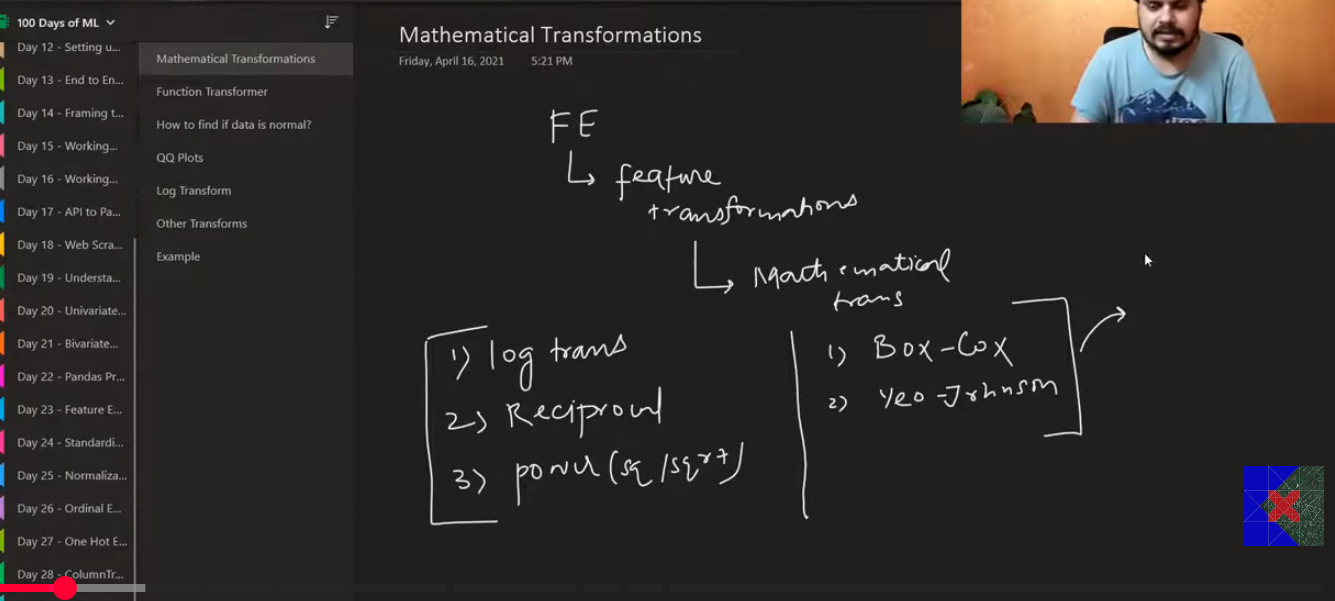

 # Mathematical tranformation
 - It is the trasformation we apply to our data column by some mathematical formula
 - Types of mathematical Transformations are: 
  1. Log Transform
  2. Reciprocal 
  3. Power
  4. Box cox 
  5. Yeo johnson
 ## what is the use of Transformation
 - Transformation help to normalize the data distribution.

# what is function Transformer?
In sklearn their are three main types of transformations.
1. funtion Transformer 
   1. Log
   2. Reciprocal
   3. square
   4. custom
2. power 
   1. box cox
   2. yeo jhonson
3. Quantile 


# How to find if data is normal?
    We can use different built in functions to find the distribution
    - seaborns distplot()
    - pandas .skewplot()
    - QQ plot
  
  <!-- ### QQ Plot  -->
  <!-- 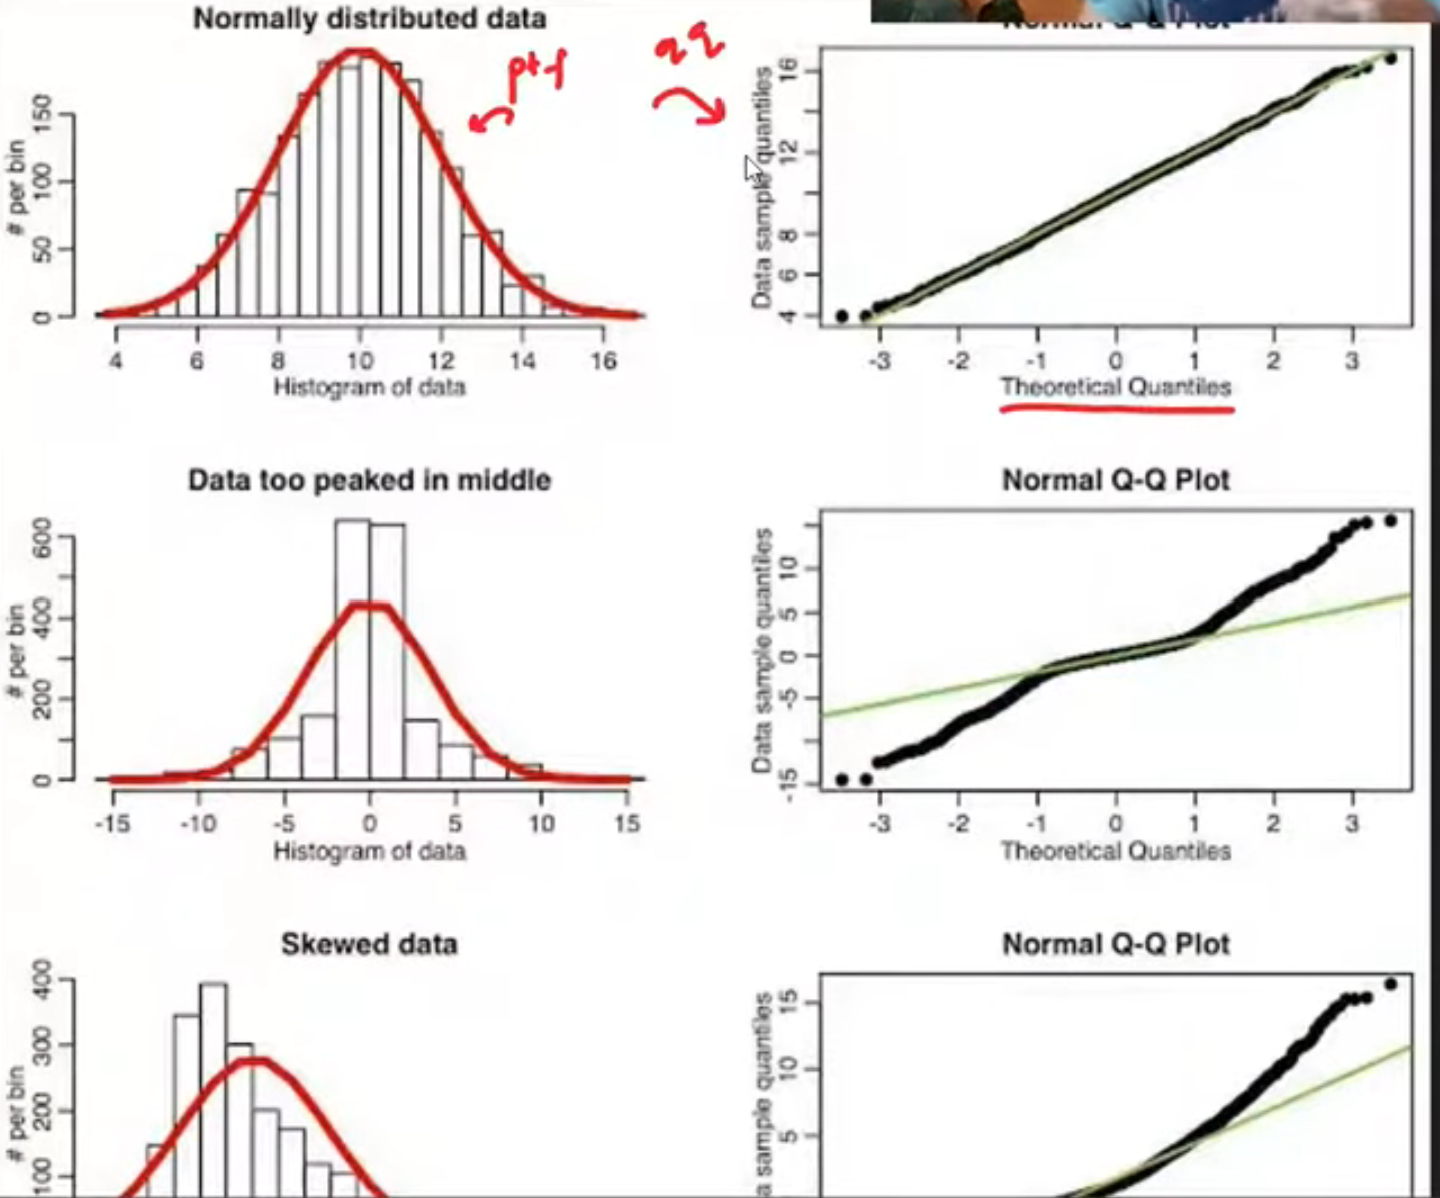 -->
  <!-- 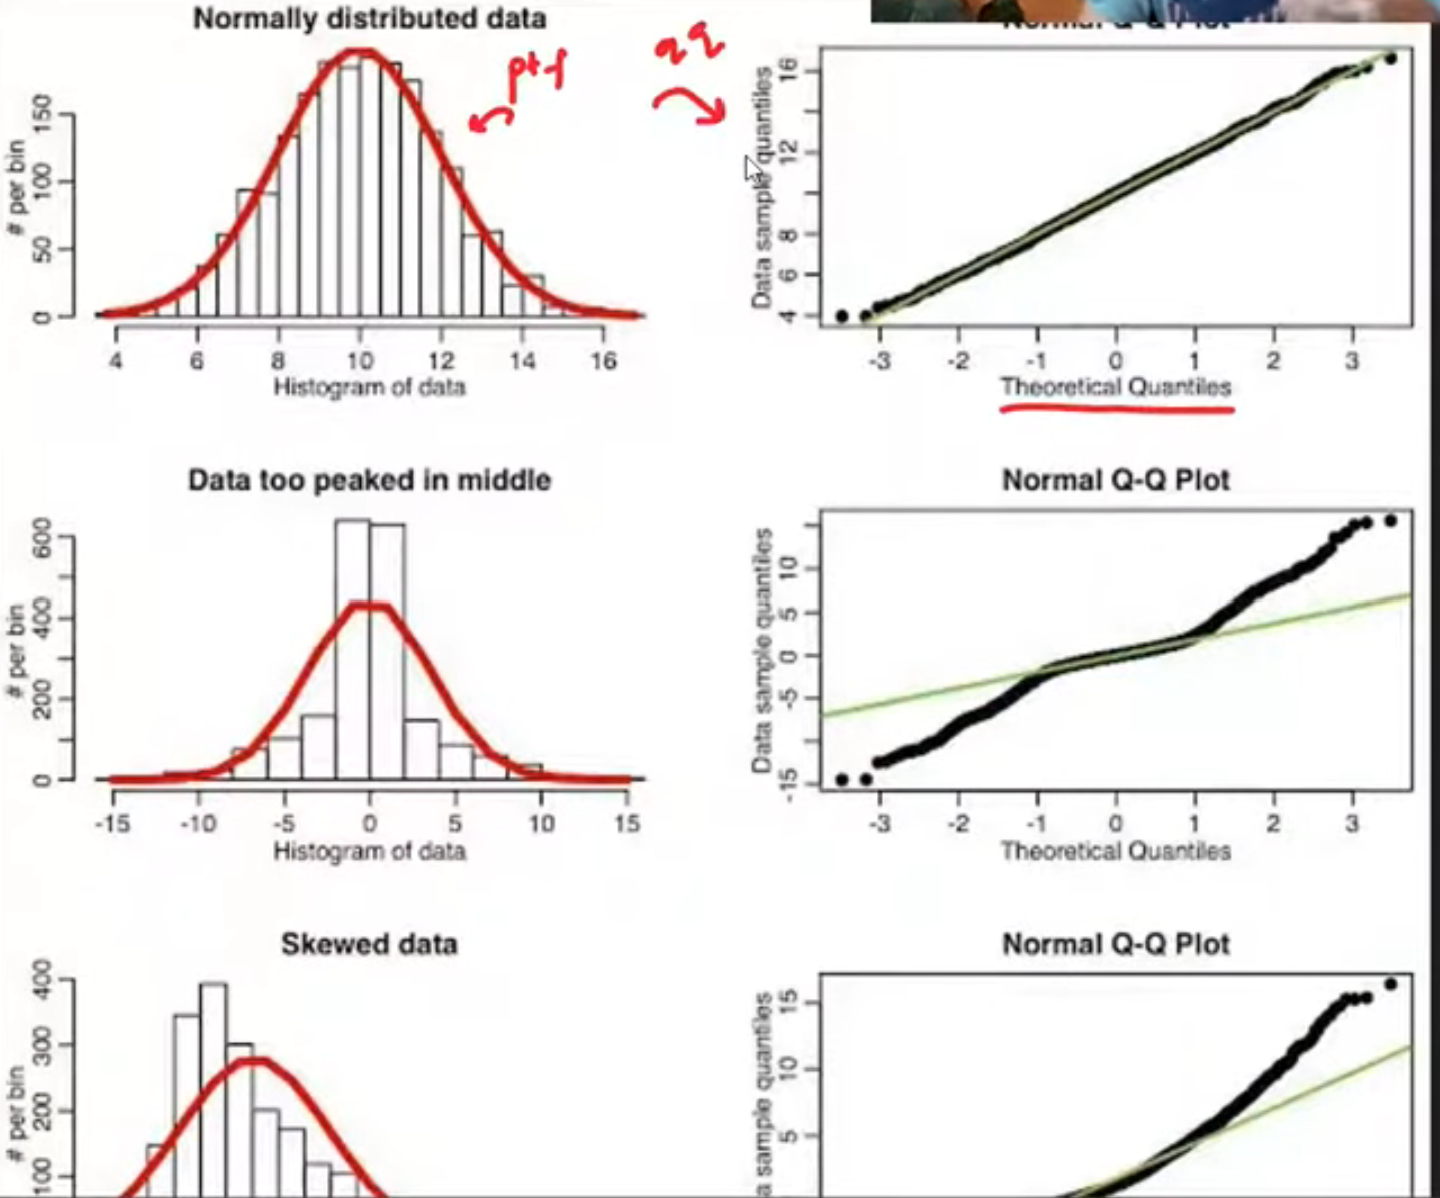 -->

## Log Transform 
By taking log of all the  values of the data of the column that we want to transform we apply log transform
- when to use log Transform?
  - we cannot apply log transform on negative value data.
  - we can apply the log transform on the right skewed data as it moves it to the normal distribution.
  -  suppose if we have three values 10 100 and 1000 and now if we takes log of all these values it becomes 1,2 and 3 . so it kind of move the far distanced values to equi distance and scale them normally.

## Reciprocal Transform (1/x)
The larger value becomes small and the smaller values becomes large.

## Square Traansform(x**2)
- it is basically used for left skewed data.

In [35]:
import pandas as pd 
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection  import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [36]:
df =pd.read_csv('E:\\WORK\\AI-ML\\data\\titanic.csv',usecols=['Age','Fare','Survived'])

In [37]:
df.head()


,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [38]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [39]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Fare'].fillna(df['Fare'].mean(),inplace=True)

C:\Users\tanma\AppData\Local\Temp\ipykernel_11784\4268719709.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\tanma\AppData\Local\Temp\ipykernel_11784\4268719709.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [40]:
X = df.iloc[:,1:3]
y= df.iloc[:,0]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

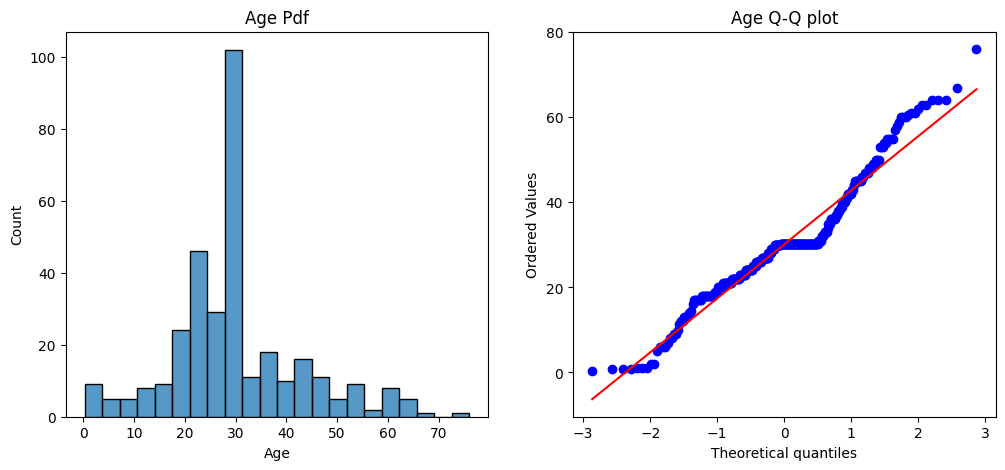

In [42]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(X_train['Age'])
plt.title('Age Pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Q-Q plot')
plt.show()

- `plt.figure(figsize=(12,5))`
  - creates a new figure window
  - sets the overall size to 12 inches wide and 5 inches tall

- `plt.subplot(121)`
  - creates the first subplot in a 1-row, 2-column grid
  - `121` means row 1, column 2, subplot 1

- `sns.distplot(X_train['Age'])`
  - plots the distribution of the `Age` column from `X_train`
  - draws a histogram and a kernel density estimate (KDE) by default

- `plt.title('Age Pdf')`
  - sets the title for the first subplot
  - labels the plot as the probability density view of `Age`

- `plt.subplot(122)`
  - switches to the second subplot in the same 1x2 grid
  - `122` means row 1, column 2, subplot 2

- `stats.probplot(X_train['Age'], dist='norm', plot=plt)`
  - creates a Q-Q plot comparing `Age` to a normal distribution
  - helps check whether `Age` is approximately normally distributed

- `plt.title('Age Q-Q plot')`
  - sets the title for the second subplot
  - labels the plot as the quantile-quantile comparison

- `plt.show()`
  - renders the figure and displays both subplots together in the notebook or screen

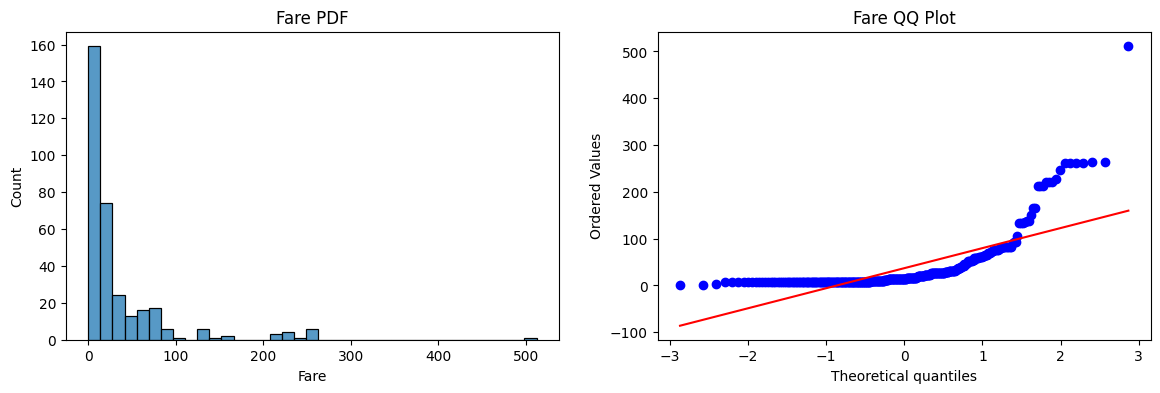

In [43]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [44]:
clf =LogisticRegression()
clf2 =DecisionTreeClassifier()

In [45]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1= clf2.predict(X_test)
print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred))
print('Decision Tree Classifier Accuracy:',accuracy_score(y_test,y_pred1))

Logistic Regression Accuracy: 0.6071428571428571
Decision Tree Classifier Accuracy: 0.5595238095238095


In [46]:
# here we are using FunctionTransformer to apply log transformation 
trf = FunctionTransformer(func=np.log1p)

In [47]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [48]:
#  after log transformation we are fitting the model again and checking the accuracy
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6190476190476191
Accuracy DT 0.5476190476190477


In [49]:
X_transformed = trf.fit_transform(X) # applying log transformation to the whole dataset

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10))) # cross validation score for Logistic Regression
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10))) # cross validation score for Decision Tree Classifier

LR 0.6556329849012775
DT 0.602787456445993


- `cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)`
  - performs 10-fold cross-validation
  - splits data into 10 parts
  - trains `clf` on 9 parts and tests on 1 part, repeated 10 times
  - returns 10 accuracy scores

- `np.mean(...)`
  - computes the average of those 10 scores
  - gives one summary performance value

- `scoring='accuracy'`
  - means each fold is scored by classification accuracy
  - accuracy = correct predictions / total predictions

- other common classification scoring options
  - `f1`
  - `precision`
  - `recall`
  - `roc_auc`
  - `balanced_accuracy`
  - `average_precision`
  - `neg_log_loss`

- multi-class variants
  - `f1_macro`, `f1_micro`, `f1_weighted`
  - `precision_macro`, `precision_weighted`
  - `recall_macro`, `recall_weighted`

- important note
  - use classification metrics for classifiers
  - use regression metrics like `neg_mean_squared_error`, `r2` only for regressors

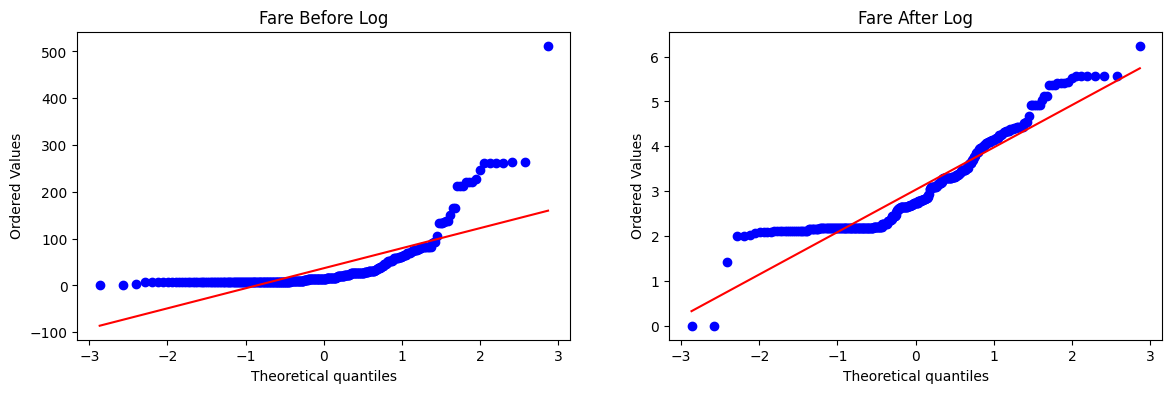

In [50]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt) # plotting the Q-Q plot after log transformation
plt.title('Fare After Log')

plt.show()

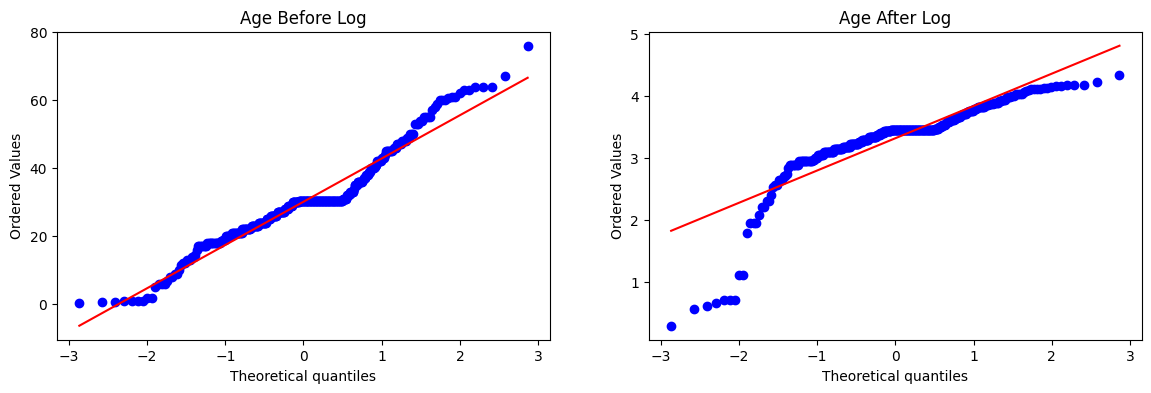

In [51]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [52]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

- `trf = FunctionTransformer(func=np.log1p)`
  - a single transformer that applies `np.log1p` to whatever data is passed into it
  - works on the whole input array or DataFrame provided to `fit_transform`
  - does not automatically preserve other columns

- `trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')`
  - applies `np.log1p` only to the `Fare` column
  - keeps the remaining columns unchanged because of `remainder='passthrough'`
  - useful when you want to transform some columns and leave others as-is

- practical difference
  - `trf` is for single-column or whole-array transformation
  - `trf2` is for column-specific transformation inside a pipeline

- when to use each
  - use `FunctionTransformer` alone when your input is already just the column(s) you want to transform
  - use `ColumnTransformer` when you have a dataset with multiple features and only some need transformation

In [53]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6190476190476191
Accuracy DT 0.5595238095238095


In [54]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6507549361207897
DT 0.5669570267131242


In [55]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6507549361207897


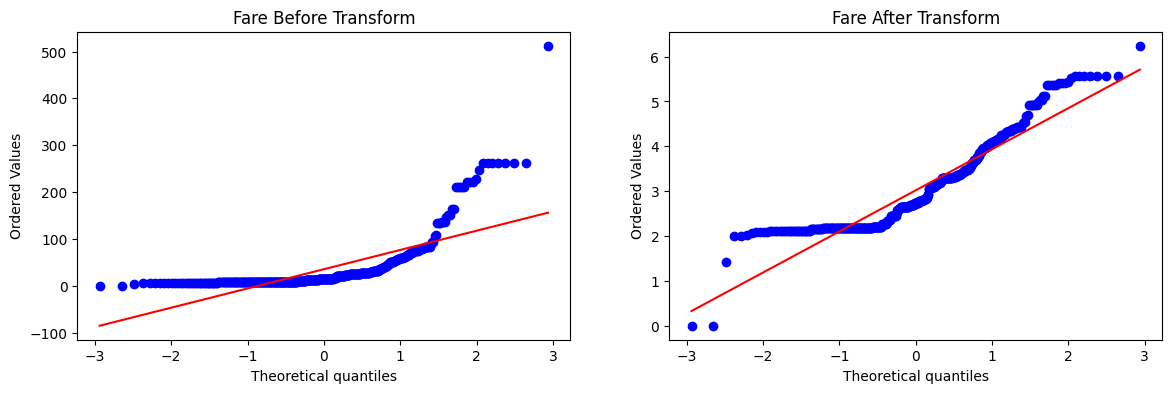

In [57]:
apply_transform(np.log1p)